# Appendix 2. PCA of the spectra

Principal component analysis of the same continuum removed spectra, over the same
wavelength window, that notebook 2 hands to UMAP -- a linear reference for the
non-linear embedding.  Nothing is written back to `results/`.

| input | what it provides |
| --- | --- |
| `metadata/params.csv` | one row per spectrum: the table built in notebook 0; fixes the row order |
| `data/F30_norm.csv` | one column per spectrum: the continuum removed fluxes built in notebook 1 |
| `results/umap_5100_6450_dim2_nei12_eps0475.csv` | the UMAP embedding of notebook 2, for the first figure only |

| output figure | what it shows |
| --- | --- |
| `figure/umap_12_with_pca.pdf` | the UMAP embedding, each spectrum coloured by its first three principal components read as red, green and blue |
| `figure/pca_cum.pdf` | how much variance each component carries, and the cumulative fraction |
| `figure/pca_spec_1sigma.pdf` | the mean spectrum and the range each of the first three components spans over +-1 sigma |


## Imports

In [1]:
import os

import numpy as np
import pandas as pd

In [2]:
import matplotlib.pyplot as plt

In [3]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import minmax_scale

## Configuration


In [4]:
# Input / output locations
PARAMS_PATH = './metadata/params.csv'
SPECTRUM_TABLE_PATH = './data/F30_norm.csv'
EMBEDDING_PATH = './results/umap_5100_6450_dim2_nei12_eps0475.csv'

FIGURE_DIR = './figure'

# Wavelength window handed to PCA [Angstrom]; the window notebook 2 gives UMAP,
# so that the two methods see the same numbers.
WINDOW_MIN_AA = 5100
WINDOW_MAX_AA = 6450

# Column label format written by notebook 1: '<SN name>%%%<SN type>$$$<phase>'
NAME_TYPE_SEPARATOR = '%%%'

# Columns notebook 2 appended to params.csv
EMBEDDING_COLUMNS = ['umap_x', 'umap_y']

In [5]:
# Components kept.  Seven is enough for the contribution ratio to have flattened
# out; the first three carry the colours and the reconstructed spectra.
N_COMPONENTS = 7
N_RGB_COMPONENTS = 3

# PC1 -> red, PC2 -> green, PC3 -> blue, in both figures that show them
RGB_COLORS = ['red', 'green', 'blue']

# Axis ratio b/a of the host above which it is seen close to face-on.  Only the
# marker depends on it: a circle for a face-on host, a star for an inclined one.
FACE_ON_RATIO = 0.7
FACE_ON_MARKER, FACE_ON_SIZE = 'o', 24
INCLINED_MARKER, INCLINED_SIZE = '*', 70

In [6]:
# Tick style shared by the figures below
plt.rcParams['figure.dpi'] = 300

plt.rcParams['xtick.direction'] = 'in'
plt.rcParams['ytick.direction'] = 'in'
plt.rcParams['xtick.bottom'] = True
plt.rcParams['xtick.top'] = True
plt.rcParams['xtick.minor.visible'] = True
plt.rcParams['ytick.minor.visible'] = True

plt.rcParams['xtick.major.width'] = 1
plt.rcParams['ytick.major.width'] = 1
plt.rcParams['xtick.minor.width'] = 0.5
plt.rcParams['ytick.minor.width'] = 0.5
plt.rcParams['xtick.major.size'] = 7
plt.rcParams['ytick.major.size'] = 7
plt.rcParams['xtick.minor.size'] = 4
plt.rcParams['ytick.minor.size'] = 4

## Reading the inputs


In [7]:
def load_params(params_path=PARAMS_PATH):
    """Read the metadata table built in notebook 0.

    Its row order becomes the row order of the fluxes and of the embedding.
    """
    return pd.read_csv(params_path)

In [8]:
def load_fluxes(params, spectrum_path=SPECTRUM_TABLE_PATH,
                window_min=WINDOW_MIN_AA, window_max=WINDOW_MAX_AA):
    """Read the normalized spectrum table of notebook 1 as one row per supernova.

    The table holds one column per spectrum, labelled
    `<SN name>%%%<SN type>$$$<phase>`, and one row per wavelength bin.  It is cut
    to the window given, transposed so that each supernova becomes a row and each
    wavelength a feature, and reordered to follow the rows of `params`.  The
    column labels of the result are the wavelengths themselves.
    """
    spectra = pd.read_csv(spectrum_path).set_index('AA')
    spectra = spectra[(spectra.index > window_min) & (spectra.index < window_max)]

    column_of = {column.split(NAME_TYPE_SEPARATOR)[0]: column for column in spectra.columns}
    if len(column_of) != len(spectra.columns):
        raise ValueError('the spectrum table holds more than one spectrum per supernova')

    # A missing supernova raises a KeyError naming it
    ordered = spectra[[column_of[name] for name in params['SN_name']]]

    return ordered.T.reset_index(drop=True)

In [9]:
def load_embedding(params, embedding_path=EMBEDDING_PATH):
    """Read the UMAP coordinates of notebook 2, in the row order of `params`.

    They are only the canvas the first figure paints the PCA colours on; the PCA
    itself never sees them.
    """
    results = pd.read_csv(embedding_path).set_index('SN_name')

    return results.loc[params['SN_name'], EMBEDDING_COLUMNS].reset_index(drop=True)

## The decomposition

`PCA` centres the fluxes on their mean, so `pca.mean_` is the mean spectrum and
every component is a deviation from it.


In [10]:
def fit_pca(fluxes, n_components=N_COMPONENTS):
    """Fit the PCA and return it together with the scores of every spectrum."""
    pca = PCA(n_components=n_components)
    scores = pca.fit_transform(fluxes)

    return pca, scores

In [11]:
def rgb_colors(scores, n_rgb=N_RGB_COMPONENTS):
    """Map the first three scores of every spectrum onto an RGB colour.

    Each component is scaled to 0-1 on its own, so a colour says where a spectrum
    sits along each of the three axes relative to the rest of the sample.
    """
    return minmax_scale(scores[:, :n_rgb])

## Run


In [12]:
params = load_params()
fluxes = load_fluxes(params)
embedding = load_embedding(params)

wavelengths = fluxes.columns.to_numpy(dtype=float)
print(f'{len(fluxes)} spectra x {fluxes.shape[1]} wavelength bins '
      f'({WINDOW_MIN_AA}-{WINDOW_MAX_AA} A)')

119 spectra x 675 wavelength bins (5100-6450 A)


In [13]:
pca, scores = fit_pca(fluxes)
colors = rgb_colors(scores)

cumulative = np.cumsum(pca.explained_variance_ratio_)
print(f'PC1-PC{N_RGB_COMPONENTS} carry {cumulative[N_RGB_COMPONENTS - 1]:.1%} of the variance, '
      f'PC1-PC{N_COMPONENTS} {cumulative[-1]:.1%}')
pd.DataFrame({'contribution': pca.explained_variance_ratio_, 'cumulative': cumulative},
             index=pd.RangeIndex(1, N_COMPONENTS + 1, name='PC'))

PC1-PC3 carry 83.7% of the variance, PC1-PC7 95.9%


,contribution,cumulative
PC,,
1,0.406645,0.406645
2,0.324005,0.730650
3,0.105883,0.836532
4,0.044568,0.881100
5,0.035774,0.916874
6,0.028070,0.944944
7,0.014118,0.959062


## Figures


In [14]:
os.makedirs(FIGURE_DIR, exist_ok=True)

### The embedding coloured by PCA

Two points of the same colour hold nearly the same spectrum as far as PCA can
tell, so a smooth run of colour across the embedding is the linear structure UMAP
kept.


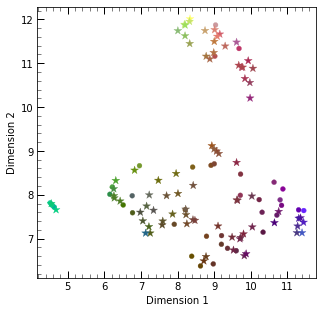

In [15]:
fig, ax = plt.subplots(figsize=(5, 5))

face_on = (params['ratio'] > FACE_ON_RATIO).to_numpy()
for selected, marker, size in [(face_on, FACE_ON_MARKER, FACE_ON_SIZE),
                               (~face_on, INCLINED_MARKER, INCLINED_SIZE)]:
    ax.scatter(embedding.loc[selected, 'umap_x'], embedding.loc[selected, 'umap_y'],
               c=colors[selected], marker=marker, s=size, linewidths=0.3)

ax.set_xlabel('Dimension 1')
ax.set_ylabel('Dimension 2')

fig.savefig(f'{FIGURE_DIR}/umap_12_with_pca.pdf', bbox_inches='tight', pad_inches=0.05)
plt.show()

### How much each component carries


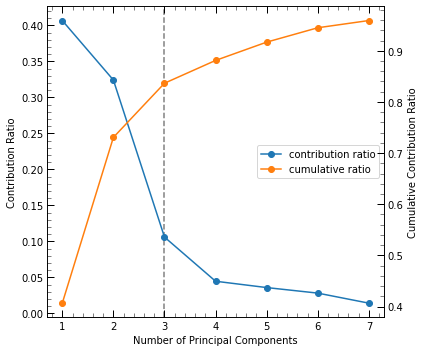

In [16]:
fig, ax = plt.subplots(figsize=(6, 5))

components = np.arange(1, N_COMPONENTS + 1)

ax.plot(components, pca.explained_variance_ratio_, color='tab:blue', marker='o',
        label='contribution ratio')
ax.axvline(N_RGB_COMPONENTS, color='grey', zorder=0, linestyle='dashed')

cumulative_axis = ax.twinx()
cumulative_axis.plot(components, cumulative, color='tab:orange', marker='o',
                     label='cumulative ratio')

ax.set_xlabel('Number of Principal Components')
ax.set_ylabel('Contribution Ratio')
cumulative_axis.set_ylabel('Cumulative Contribution Ratio')

handles, labels = ax.get_legend_handles_labels()
cumulative_handles, cumulative_labels = cumulative_axis.get_legend_handles_labels()
ax.legend(handles + cumulative_handles, labels + cumulative_labels, loc='center right')

fig.tight_layout()
fig.savefig(f'{FIGURE_DIR}/pca_cum.pdf', bbox_inches='tight', pad_inches=0.05)
plt.show()

### What each component does to the spectrum

The mean spectrum, with a band per component: the spectra reconstructed at +-1
sigma of that component alone, sigma being the spread of the sample along it.


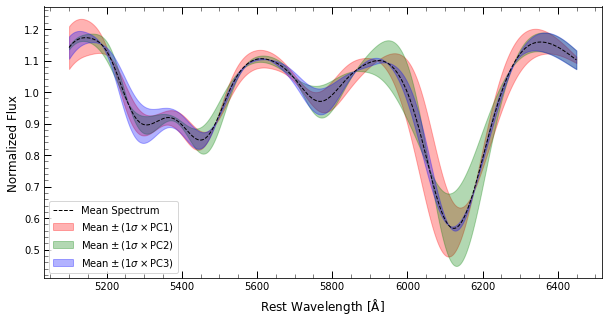

In [17]:
fig, ax = plt.subplots(figsize=(10, 5))

sigma = scores.std(axis=0)

ax.plot(wavelengths, pca.mean_, 'k--', linewidth=1, label='Mean Spectrum')
for component, color in enumerate(RGB_COLORS):
    deviation = sigma[component] * pca.components_[component]
    ax.fill_between(wavelengths, pca.mean_ - deviation, pca.mean_ + deviation,
                    color=color, alpha=0.3,
                    label=rf'$\mathrm{{Mean}} \pm (1\sigma \times \mathrm{{PC{component + 1}}})$')

ax.set_xlabel(r'Rest Wavelength [$\rm \AA$]', fontsize=12)
ax.set_ylabel('Normalized Flux', fontsize=12)
ax.legend()

fig.savefig(f'{FIGURE_DIR}/pca_spec_1sigma.pdf', bbox_inches='tight', pad_inches=0.05)
plt.show()